In [1]:
import numpy as np
from utilities import states_from_fortran_restarts, setup_infrastructure

from pySHiELD.radiation import RadiationState, RadiationConfig, RTE_RRTMGPDriver
from pySHiELD.physics_state import SurfaceState, PhysicsState, PHYSICS_PACKAGES
from pySHiELD._config import PhysicsConfig
from pySHiELD.stencils.physics import Physics

import matplotlib.pyplot as plt
import datetime
from pathlib import Path

2025-08-02 11:54:26|INFO|rank 0|ndsl.logging:Constant selected: ConstantVersions.UFS


In [2]:
dycore_data = Path("../../test_data/radtest/fv_core.res.tile1.nc")
phys_data = Path("../../test_data/radtest/phy_data.tile1.nc")
tracer_data = Path("../../test_data/radtest/fv_tracer.res.tile1.nc")

In [3]:
nx = 48
ny = 48
nz = 91
npx = nx + 1
npy = ny + 1
npz = nz + 1
levels = np.arange(npz)
layers = np.arange(nz)

date = datetime.datetime(2020, 1, 1, 12, tzinfo=datetime.timezone.utc)

In [4]:
quantity_factory, stencil_factory, grid_data = setup_infrastructure(nx, ny, nz, "eta91.nc")
# Quick fix:
grid_data.lon_agrid.field[:] = grid_data.lon.field[:-1,:-1]
grid_data.lat_agrid.field[:] = grid_data.lat.field[:-1,:-1]

In [5]:
conf = PhysicsConfig(
    dt_atmos=225.0,
    fhswr=225.0,
    fhlwr=225.0,
    npx=npx,
    npy=npy,
    npz=npz,
    nwat=6,
    prescribe_sst=False,
)
radconf = RadiationConfig(
    deltsw = 3600.0,
    delt_rad = 3600.0,
    date=date,
    fhswr=1.0,
    fhlwr=1.0,
    isolar=10,
    icmphys=4,
    ico2flg=0,
    ioznflg=1,
    ictmflg=-1,
    ialbflg=-1,
    iemsflg=0,
    ldisable_radiation_quasi_sea_ice=False,
    solar_constant_file=Path("global_solarconstant_noaa_an.txt"),
    input_dir=Path("../../test_data/"),
    aerosol_file=Path("../../test_data/"),
    sollat=0.0,
    nstp=6,
    ivflip=1,
    lcnorm=False,
    lcrick=False,
    gfs_cloud_overlap=False,
)

In [6]:
state, radstate, sstate = states_from_fortran_restarts(dycore_data, phys_data, tracer_data, grid_data.ak, quantity_factory, conf.schemes)

In [8]:
physics = Physics(
    stencil_factory,
    quantity_factory,
    grid_data,
    conf,
    radconf,
)

2025-08-02 11:55:13|INFO|rank 0|ndsl.logging:GFS_microphysics enabled
2025-08-02 11:55:13|INFO|rank 0|ndsl.logging:RTE_RRTMGP enabled
2025-08-02 11:55:15|INFO|rank 0|ndsl.logging: - Using new fixed solar constant = 1360.8
2025-08-02 11:55:15|INFO|rank 0|ndsl.logging:Using Constant Albedo 0.98
2025-08-02 11:55:15|INFO|rank 0|ndsl.logging:Enable radiation quasi-sea-ice
2025-08-02 11:55:15|INFO|rank 0|ndsl.logging:Using Fixed Surface Emissivity = 1.0 for lw


/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dq` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `r1__f66_92_19` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `ze` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt` may be uninitialized.
  result = step(result)
/Users/oliverelbert/anaconda3/envs/pyshield/lib/python3.11/

In [9]:
physics(state, radstate, sstate, date, conf.dt_atmos)

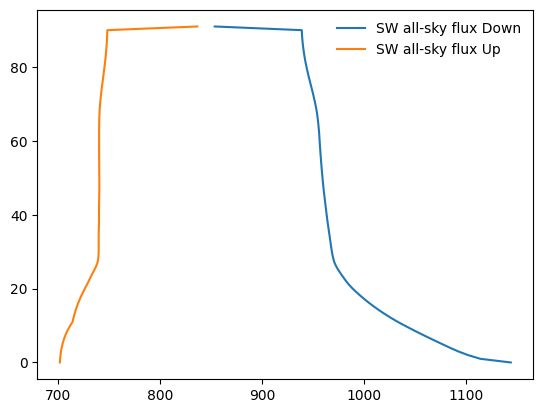

In [14]:
plt.plot(radstate.fswd.view[0,0,:], levels, label="SW all-sky flux Down")
plt.plot(radstate.fswu.view[0,0,:], levels, label="SW all-sky flux Up")
plt.legend(frameon=False)

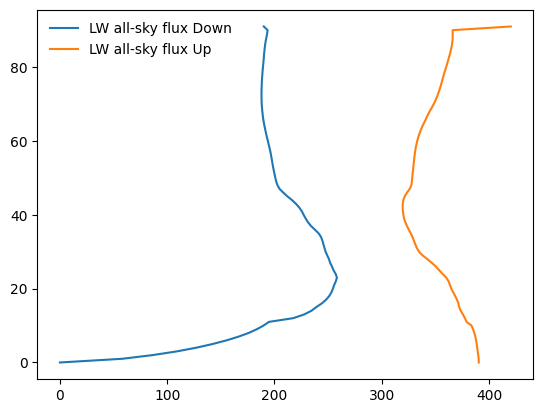

In [16]:
plt.plot(radstate.flwd.view[0,0,:], levels, label="LW all-sky flux Down")
plt.plot(radstate.flwu.view[0,0,:], levels, label="LW all-sky flux Up")
plt.legend(frameon=False)